In [1]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score
from underthesea import word_tokenize
import re
import warnings
warnings.filterwarnings('ignore')

In [3]:
youtube_cmt = pd.read_excel('/content/drive/MyDrive/Dataset-Training-ML/Tram_dung_chan_Jack_shuffled.xlsx')
youtube_cmt = youtube_cmt[["textDisplay","label"]]

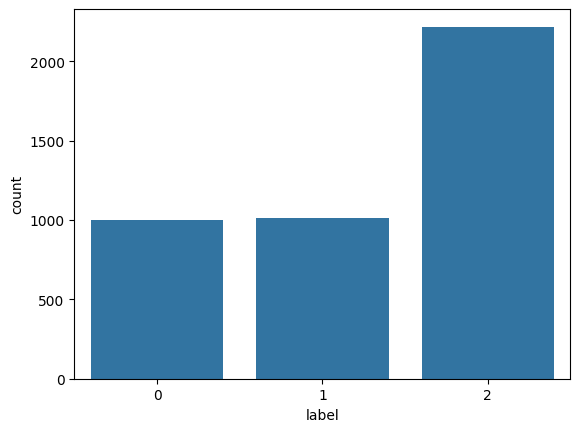

In [4]:
sns.countplot(data=youtube_cmt, x='label')
plt.show()

In [5]:
TEENCODE_DICT = {
    'ko': 'không', 'k': 'không', 'kh': 'không',
    'bt': 'biết',
    'dc': 'được', 'đc': 'được',
    "ak":"à","àh":"à",
    "uk":"ừ","uh":"ừ",
    "cmnl":"con mẹ nó luôn",
    'ad': 'admin',
    'ntn': 'như thế nào',
    'v': 'vậy',
    'r': 'rồi',
    "qtr":"quá trời",
    'cx': 'cũng',
    'ib': 'inbox',
    'rep': 'trả lời',
    'mn': 'mọi người',
    'cmt': 'comment',
    'b': 'bạn',
    "tr":"trời",
    'e': 'em',
    'a': 'anh',
    "ng":"người",
    "lm":"làm",
    "cầu đặc":"đầu cặc","kẹc":"cặc",
    "đ":"đéo",
    "gđ":"gia đình",
    "cằk":"cặc","cặk":"cặc",
    'okela':'ok',
    "djt":"địt",
    "trây":"jack",
    "bn":"bao nhiêu","bnh":"bao nhiêu",
    "cmm":"con mẹ","cm":"chúng mày","clm":"cái lồn má",
    'vc':'vãi cả',
    'cc':'cục cứt',
    "j":"jack",
    'loz':'lồn', 'l':'lồn', "lol":"lồn","lòn":"lồn",
    'vl':'vãi lồn',"vcl":"vãi cả lồn","vkl":"vãi cả lồn",
    "đcm":"địt con mẹ","đm":"địt mẹ","đcmm":"địt con mẹ","đcmmm":"địt con mẹ",
    "đb":"đầu buồi",
    'deo':'đéo','dell':'đéo',
    'vcc':"vãi cả cứt",
    "occho":"óc chó",
    "t":"tôi",
    "chx":"chưa",
    "xg":"xong",
    "vcd":"vãi cả đái","vcđ":"vãi cả đái",
    "ae":"anh em",
    "j":"gì",
    "lôn":"lồn",
    "soll":"son","sol":"son",
    "vaiz":"vãi",
    "mn":"mọi người","mng":"mọi người",
    "bth":"bình thường",
    "m":"mày",
    "cm":"chúng mày",
    "ch":"chưa",
    "vs":"với",
    "sv":"súc vật",
    "c":"cứt",
    "t.o.p":"top",
    "ncc":"như cục cứt",
    "dit":"địt","djt":"địt",
    "sky":"sơn tùng",
    "hth":"hiếu thứ hai",
    "qc":"quảng cáo",
    "vn":"việt nam",
    "vaiz":"vãi",
    "r":"rồi",
    "nge":"nghe",
    "tiktok":"tik tok",
    "ytb":"youtube", "fb":"facebook",
    "vcut":"vãi cứt","shit":"cứt",
    "fl":"follow"
}

EMOJI_DICT = {
    "😢":" bieu_tuong_buon ",
    "🎉":" bieu_tuong_chuc_mung ",
    "❤":" bieu_tuong_trai_tim ",
    "🤣":" bieu_tuong_mat_cuoi ", "😂":" bieu_tuong_mat_cuoi ",
    "😭":" bieu_tuong_khoc ",
    "🔥":" bieu_tuong_chay ",
    "💩":" bieu_tuong_cut ",
    "🥰":" bieu_tuong_yeu_thuong ",
    "😮":" bieu_tuong_ngac_nhien ",
    "😅":" bieu_tuong_lo_lang ",
    "<3":" bieu_tuong_trai_tim "
}

STOP_WORDS = set()
with open('/content/drive/MyDrive/Dataset-Training-ML/vietnamese-stopwords-dash.txt', 'r', encoding='utf-8') as file:
    for line in file:
        word = line.strip()  # Loại bỏ ký tự xuống dòng và khoảng trắng
        if word:  # Đảm bảo từ không rỗng
            STOP_WORDS.add(word)


In [6]:
def preprocessing_basic(text):
  text = text.lower()
  text = re.sub(r'http\S+','',text)
  text = re.sub(r'<.*?>', '', text)
  text = text.strip()
  text = text.replace("t o p","top").replace("tốp","top")
  text = text.replace("v i e w","view").replace("c à y","cày")
  text = text.replace("đốn lòm","đóm lồn").replace("đốm lòn","đóm lồn")
  return text

In [7]:
def replace_teencode(text,teencode_dict):
  words = text.split()

  for idx,each_word in enumerate(words):
    if each_word in teencode_dict:
      words[idx] = teencode_dict[each_word]

  return ' '.join(words)

In [8]:
def replace_emoji(text,emoji_dict):
  for emoji, word in emoji_dict.items():
      text = text.replace(emoji, word)

  text = re.sub(r'\s+', ' ', text).strip()
  return text

In [9]:
def remove_stop_words(text):
  global STOP_WORDS
  words = text.split()

  filtered_words = [word for word in words if word not in STOP_WORDS or word == "hay"]

  return ' '.join(filtered_words)


In [10]:
def keep_chars(text):
  vietnamese_chars = 'àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ'
  # Whitelist bao gồm: chữ cái a-z, chữ cái tiếng Việt, và dấu gạch dưới
  allowed_chars = vietnamese_chars + 'a-z_'

  # Tạo pattern để tìm các ký tự KHÔNG thuộc whitelist (và cũng không phải khoảng trắng)
  unwanted_chars_pattern = re.compile(f'[^{allowed_chars}\s]')
  text = unwanted_chars_pattern.sub(' ', text)
  text = re.sub(r'\s+',' ',text)
  text = text.strip()
  return text

In [11]:
def preprocess_comment(text):
    global TEENCODE_DICT
    global EMOJI_DICT
    global STOP_WORDS

    text = preprocessing_basic(text)
    text = replace_teencode(text, TEENCODE_DICT)
    text = replace_emoji(text,EMOJI_DICT)
    text = keep_chars(text)


    # Tách từ cho có nghĩa
    text = word_tokenize(text, format="text")
    text = remove_stop_words(text)

    return text

In [12]:
# Lọc trùng bình luận (tránh seeding)
youtube_cmt = youtube_cmt.drop_duplicates(subset=['textDisplay'], keep='first')

In [13]:
youtube_cmt["textDisplay"] = youtube_cmt["textDisplay"].fillna("").apply(preprocess_comment)

In [14]:
comments = youtube_cmt["textDisplay"]
labels = youtube_cmt["label"]

In [15]:
comments_train, comments_test, y_train, y_test = train_test_split(
    comments, labels, test_size=0.2, stratify=labels, random_state=42
)

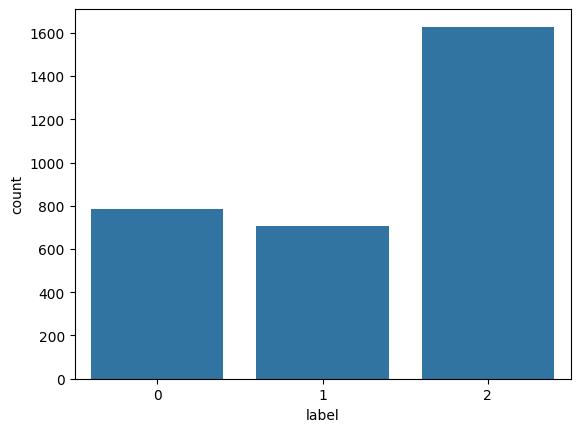

In [16]:
sns.countplot(x=pd.Series(y_train))
plt.show()

In [17]:
# Sử dụng TfidVectorizer
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train = vectorizer.fit_transform(comments_train)

X_test = vectorizer.transform(comments_test)

In [18]:
# Kiểm tra kết quả
print("Kích thước của ma trận X_train (số bình luận, số feature):", X_train.shape)
print("\nMột vài feature (từ) mà vectorizer đã học được:")

# Lấy 10 feature đầu tiên
print(vectorizer.get_feature_names_out()[:10])

Kích thước của ma trận X_train (số bình luận, số feature): (3120, 5000)

Một vài feature (từ) mà vectorizer đã học được:
['__nghe thấm' '__nhac' '__nhac hoa' '_x' '_x d_' '_x d__cố' '_x_d_'
 '_x_d_ _x' '_x_d_ _x_d_' '_x_d_ sớm_mai']


In [19]:
# Setup cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [20]:
models = {
    'LogisticRegression': LogisticRegression(random_state=42, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'SVM': SVC(random_state=42,class_weight='balanced', kernel='linear'),
    'NaiveBayes':MultinomialNB(alpha=0.1)
}

In [21]:
# Cross-validation cho mỗi model
results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_weighted')
    results[name] = {
        'mean_f1': cv_scores.mean(),
        'std_f1': cv_scores.std()
    }

In [22]:
for key in results:
  print("Model:",key,"Value",results[key])

Model: LogisticRegression Value {'mean_f1': np.float64(0.6660744748272294), 'std_f1': np.float64(0.01891242798667113)}
Model: RandomForest Value {'mean_f1': np.float64(0.656957332871446), 'std_f1': np.float64(0.010406747374277917)}
Model: SVM Value {'mean_f1': np.float64(0.666934218751192), 'std_f1': np.float64(0.022415622055915126)}
Model: NaiveBayes Value {'mean_f1': np.float64(0.6595904358597391), 'std_f1': np.float64(0.011159485833046483)}


-> Logistic Regression tốt nhất

In [23]:
# Tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000, 2000]
}
grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid, cv=5, scoring='f1_weighted', n_jobs=-1
)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'max_iter': [1000, 2000],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1_weighted')

In [24]:
print(f"Best params: {grid.best_params_}")
print(f"Best CV score: {grid.best_score_:.3f}")

Best params: {'C': 10, 'max_iter': 1000, 'solver': 'liblinear'}
Best CV score: 0.678


In [25]:
def essential_evaluation(model, X_train, y_train, X_test, y_test):
    """
    Đánh giá essential metrics + check overfitting + classification report
    """
    print("🎯 ESSENTIAL METRICS + OVERFITTING CHECK + REPORT")
    print("=" * 60)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # === CORE METRICS (Train vs Test) ===
    # ... (code giống như cũ) ...
    # Train performance
    train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
    train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
    train_bal_acc = balanced_accuracy_score(y_train, y_train_pred)

    # Test performance
    test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
    test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)

    # === RESULTS TABLE ===
    print(f"{'Metric':<20} {'Train':<8} {'Test':<8} {'Gap':<8} {'Status'}")
    print("-" * 55)

    # F1-weighted (most important)
    gap_weighted = train_f1_weighted - test_f1_weighted
    status_weighted = "🟢 Good" if gap_weighted < 0.05 else ("🟡 Mild" if gap_weighted < 0.10 else "🔴 Overfit")
    print(f"{'F1-Weighted':<20} {train_f1_weighted:<8.4f} {test_f1_weighted:<8.4f} {gap_weighted:<8.4f} {status_weighted}")

    # F1-macro
    gap_macro = train_f1_macro - test_f1_macro
    status_macro = "🟢 Good" if gap_macro < 0.05 else ("🟡 Mild" if gap_macro < 0.10 else "🔴 Overfit")
    print(f"{'F1-Macro':<20} {train_f1_macro:<8.4f} {test_f1_macro:<8.4f} {gap_macro:<8.4f} {status_macro}")

    # Balanced Accuracy
    gap_bal = train_bal_acc - test_bal_acc
    status_bal = "🟢 Good" if gap_bal < 0.05 else ("🟡 Mild" if gap_bal < 0.10 else "🔴 Overfit")
    print(f"{'Balanced-Acc':<20} {train_bal_acc:<8.4f} {test_bal_acc:<8.4f} {gap_bal:<8.4f} {status_bal}")

    # === OVERALL ASSESSMENT ===
    print(f"\n🏆 FINAL ASSESSMENT:")
    print(f"Primary Score (F1-weighted): {test_f1_weighted:.4f}")

    max_gap = max(gap_weighted, gap_macro, gap_bal)
    if max_gap < 0.05:
        print("✅ NO OVERFITTING - Model generalizes well!")
    elif max_gap < 0.10:
        print("⚠️  MILD OVERFITTING - Acceptable but monitor")
    else:
        print("❌ SIGNIFICANT OVERFITTING - Need regularization!")

    # === DETAILED CLASSIFICATION REPORT (cho Test set) ===
    print("\n📊 DETAILED CLASSIFICATION REPORT (Test Set):")
    print("-" * 50)

    # Tên classes (thay đổi nếu cần)
    target_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']
    print(classification_report(y_test, y_test_pred, target_names=target_names, digits=4))


# === USAGE ===
# Với GridSearch best model
best_model = grid.best_estimator_
essential_evaluation(best_model, X_train, y_train, X_test, y_test)

🎯 ESSENTIAL METRICS + OVERFITTING CHECK + REPORT
Metric               Train    Test     Gap      Status
-------------------------------------------------------
F1-Weighted          0.9124   0.7053   0.2071   🔴 Overfit
F1-Macro             0.9063   0.6772   0.2291   🔴 Overfit
Balanced-Acc         0.9171   0.6807   0.2364   🔴 Overfit

🏆 FINAL ASSESSMENT:
Primary Score (F1-weighted): 0.7053
❌ SIGNIFICANT OVERFITTING - Need regularization!

📊 DETAILED CLASSIFICATION REPORT (Test Set):
--------------------------------------------------
              precision    recall  f1-score   support

Negative (0)     0.7638    0.7755    0.7696       196
 Neutral (1)     0.4767    0.5198    0.4973       177
Positive (2)     0.7835    0.7469    0.7648       407

    accuracy                         0.7026       780
   macro avg     0.6747    0.6807    0.6772       780
weighted avg     0.7089    0.7026    0.7053       780



### Fixing overfitting

In [26]:
param_grid_regularized = {
    'C': [0.001, 0.01, 0.1, 1],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000],
    'penalty': ['l1', 'l2']
}
grid_reg = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid_regularized,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
grid_reg.fit(X_train, y_train)

print("New best params:", grid_reg.best_params_)
print("New CV score:", grid_reg.best_score_)

New best params: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
New CV score: 0.6707716253937737


In [27]:
best_model = grid_reg.best_estimator_
results = essential_evaluation(best_model, X_train, y_train, X_test, y_test)

🎯 ESSENTIAL METRICS + OVERFITTING CHECK + REPORT
Metric               Train    Test     Gap      Status
-------------------------------------------------------
F1-Weighted          0.8586   0.6907   0.1679   🔴 Overfit
F1-Macro             0.8516   0.6696   0.1820   🔴 Overfit
Balanced-Acc         0.8749   0.6841   0.1907   🔴 Overfit

🏆 FINAL ASSESSMENT:
Primary Score (F1-weighted): 0.6907
❌ SIGNIFICANT OVERFITTING - Need regularization!

📊 DETAILED CLASSIFICATION REPORT (Test Set):
--------------------------------------------------
              precision    recall  f1-score   support

Negative (0)     0.7376    0.7602    0.7487       196
 Neutral (1)     0.4545    0.6215    0.5251       177
Positive (2)     0.8125    0.6708    0.7349       407

    accuracy                         0.6821       780
   macro avg     0.6682    0.6841    0.6696       780
weighted avg     0.7125    0.6821    0.6907       780



-> Có giảm nhưng không đáng kể

In [28]:
vectorizer_simple = TfidfVectorizer(
    max_features= 4000,
    ngram_range=(1, 1),
    min_df=3,
    max_df=0.8
)

X_train = vectorizer_simple.fit_transform(comments_train)

X_test = vectorizer_simple.transform(comments_test)


In [29]:
grid_reg.fit(X_train, y_train)
print("New best params:", grid_reg.best_params_)
print("New CV score:", grid_reg.best_score_)

New best params: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
New CV score: 0.6795549550584068


In [30]:
best_model = grid_reg.best_estimator_
essential_evaluation(best_model, X_train, y_train, X_test, y_test)

🎯 ESSENTIAL METRICS + OVERFITTING CHECK + REPORT
Metric               Train    Test     Gap      Status
-------------------------------------------------------
F1-Weighted          0.7756   0.6873   0.0883   🟡 Mild
F1-Macro             0.7559   0.6598   0.0961   🟡 Mild
Balanced-Acc         0.7630   0.6643   0.0987   🟡 Mild

🏆 FINAL ASSESSMENT:
Primary Score (F1-weighted): 0.6873
⚠️  MILD OVERFITTING - Acceptable but monitor

📊 DETAILED CLASSIFICATION REPORT (Test Set):
--------------------------------------------------
              precision    recall  f1-score   support

Negative (0)     0.7344    0.7194    0.7268       196
 Neutral (1)     0.4645    0.5537    0.5052       177
Positive (2)     0.7772    0.7199    0.7474       407

    accuracy                         0.6821       780
   macro avg     0.6587    0.6643    0.6598       780
weighted avg     0.6955    0.6821    0.6873       780



### Ý tưởng tiếp theo: ta sử dụng Ensemble - VotingClassifier

In [31]:
# Tôi đang phân vân chọn giữa LR + SVM hoặc LR + NB. Ta kiểm tra
# === Ensemble LR + SVM ===
lr_best = LogisticRegression(C=1,max_iter=1000, penalty='l2', class_weight='balanced', random_state=42)
ensemble_svm = VotingClassifier([
    ('lr', lr_best),
    ('svm', SVC(kernel='linear', C=0.01, class_weight='balanced', probability=True, random_state=42))  # probability=True cho soft voting
], voting='soft')

ensemble_svm.fit(X_train, y_train)
print("\n🎉 Ensemble LR + SVM Eval:")
essential_evaluation(ensemble_svm, X_train, y_train, X_test, y_test)

print("")

# === So sánh với Ensemble LR + NB ===
ensemble_nb = VotingClassifier([
    ('lr', lr_best),
    ('nb',MultinomialNB(alpha=0.1))
], voting='soft')

ensemble_nb.fit(X_train, y_train)
print("\n🎉 Ensemble LR + NaiveBayes:")
essential_evaluation(ensemble_nb, X_train, y_train, X_test, y_test)


🎉 Ensemble LR + SVM Eval:
🎯 ESSENTIAL METRICS + OVERFITTING CHECK + REPORT
Metric               Train    Test     Gap      Status
-------------------------------------------------------
F1-Weighted          0.7545   0.6834   0.0711   🟡 Mild
F1-Macro             0.7243   0.6346   0.0897   🟡 Mild
Balanced-Acc         0.7059   0.6232   0.0827   🟡 Mild

🏆 FINAL ASSESSMENT:
Primary Score (F1-weighted): 0.6834
⚠️  MILD OVERFITTING - Acceptable but monitor

📊 DETAILED CLASSIFICATION REPORT (Test Set):
--------------------------------------------------
              precision    recall  f1-score   support

Negative (0)     0.8024    0.6837    0.7383       196
 Neutral (1)     0.5765    0.2768    0.3740       177
Positive (2)     0.7008    0.9091    0.7914       407

    accuracy                         0.7090       780
   macro avg     0.6932    0.6232    0.6346       780
weighted avg     0.6981    0.7090    0.6834       780



🎉 Ensemble LR + NaiveBayes:
🎯 ESSENTIAL METRICS + OVERFITTING CHE

-> Chọn LR + SVM

In [32]:
# Tuning cho SVM
svm_param_grid = {
    'C': [0.001, 0.01, 0.03, 0.05],
    'kernel': ['linear', 'rbf','poly'],
    'gamma': ['scale', 'auto'],       # Chỉ áp dụng cho rbf, poly
    'class_weight': ['balanced']      # Handle imbalance
}
svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),  # probability=True cho soft voting sau
    svm_param_grid,
    cv=5,                                    # 5-fold CV
    scoring='f1_weighted',                   # Primary metric
    n_jobs=-1,                               # Parallel processing
    verbose=1                                # Show progress
)

In [35]:
lr_best = LogisticRegression(C=1,max_iter=1000, penalty='l2', class_weight='balanced', random_state=42)
svc_best = SVC(kernel='rbf', C=0.03, class_weight='balanced', probability=True, gamma='scale', random_state=42)
ensemble_svm = VotingClassifier([
    ('lr', lr_best),
    ('svm', svc_best)
], voting='soft')

ensemble_svm.fit(X_train, y_train)
print("\n🎉 Ensemble LR + SVM Eval:")
essential_evaluation(ensemble_svm, X_train, y_train, X_test, y_test)


🎉 Ensemble LR + SVM Eval:
🎯 ESSENTIAL METRICS + OVERFITTING CHECK + REPORT
Metric               Train    Test     Gap      Status
-------------------------------------------------------
F1-Weighted          0.7721   0.6932   0.0790   🟡 Mild
F1-Macro             0.7502   0.6579   0.0923   🟡 Mild
Balanced-Acc         0.7468   0.6551   0.0918   🟡 Mild

🏆 FINAL ASSESSMENT:
Primary Score (F1-weighted): 0.6932
⚠️  MILD OVERFITTING - Acceptable but monitor

📊 DETAILED CLASSIFICATION REPORT (Test Set):
--------------------------------------------------
              precision    recall  f1-score   support

Negative (0)     0.7358    0.7245    0.7301       196
 Neutral (1)     0.4938    0.4520    0.4720       177
Positive (2)     0.7553    0.7887    0.7716       407

    accuracy                         0.6962       780
   macro avg     0.6616    0.6551    0.6579       780
weighted avg     0.6911    0.6962    0.6932       780



### Nhận xét:
+ Mô hình đạt được chỉ số F1-weighted là 0.6932 trên tập Test, một kết quả khả quan cho baseline.
+ Mức độ chênh lệch (Gap) giữa tập Train và Test dao động trong khoảng ~7-8%. Điều này cho thấy có hiện tượng overfitting ở mức độ nhẹ, tuy nhiên vẫn nằm trong ngưỡng chấp nhận được và mô hình có khả năng tổng quát hóa khá tốt.
+ Điểm mạnh: Mô hình hoạt động rất hiệu quả với các lớp Tích cực (F1=0.77) và Tiêu cực (F1=0.73).
+ Điểm yếu: Hiệu suất trên lớp Trung tính (F1=0.47) là rất thấp. Đây là узкое место (bottleneck) chính của mô hình, nguyên nhân có thể do sự thiếu các từ khóa cảm xúc rõ ràng trong các bình luận trung tính và số lượng mẫu ít hơn.

### Đề xuất hành động:
+ Chuyển sang Deep Learning: Ưu tiên hàng đầu là áp dụng các mô hình Transformer như PhoBERT, vốn được thiết kế để hiểu ngữ cảnh sâu sắc của ngôn ngữ tiếng Việt. Đây được kỳ vọng sẽ là giải pháp mang lại bước đột phá về hiệu suất.
+ Tăng cường dữ liệu: Tiếp tục đánh nhãn thêm cho nhãn 1 để cho mô hình dự đoán tốt hơn. Mặt khác cũng đánh nhãn thêm 2,0 nếu muốn hiệu suất tốt hơn